In [1]:
from sklearn import __version__ as sklearn_version

sklearn_version

'1.9.0'

# Examples of validation curves
Let's load up the LFW Faces dataset and continue to perform some analysis, this time using learning curves and validation curves inour analysis. 
 
Much of this code is manipulated from :
- https://github.com/rasbt/python-machine-learning-book/blob/master/code/ch06/ch06.ipynb

In [2]:
from sklearn.datasets import fetch_lfw_people

lfw_people = fetch_lfw_people(min_faces_per_person=50, resize=None)

# get some of the specifics of the dataset
X = lfw_people.data
y = lfw_people.target
names = lfw_people.target_names

n_samples, n_features = X.shape
_, h, w = lfw_people.images.shape
n_classes = len(names)

print("n_samples: {}".format(n_samples))
print("n_features: {}".format(n_features))
print("n_classes: {}".format(n_classes))
print("Original Image Sizes {}by{}".format(h,w))
print (125*94) # the size of the images are the size of the feature vectors

n_samples: 1560
n_features: 11750
n_classes: 12
Original Image Sizes 125by94
11750


In [3]:
if sklearn_version < '0.18':
    from sklearn.cross_validation import train_test_split
else:
    from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=1)

In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

pipe_lr = Pipeline([('scl', StandardScaler()),
                    ('pca', PCA(n_components=200,random_state=1)),
                    ('clf', LogisticRegression(class_weight='balanced', max_iter=500))])

pipe_lr.fit(X_train, y_train)
y_pred = pipe_lr.predict(X_test)
print(classification_report(y_test, y_pred, target_names=names))

                   precision    recall  f1-score   support

     Ariel Sharon       0.75      0.69      0.72        13
     Colin Powell       0.82      0.82      0.82        50
  Donald Rumsfeld       0.71      0.75      0.73        20
    George W Bush       0.91      0.87      0.89       118
Gerhard Schroeder       0.73      0.84      0.78        19
      Hugo Chavez       0.83      0.77      0.80        13
   Jacques Chirac       0.38      0.50      0.43         6
    Jean Chretien       0.89      0.67      0.76        12
    John Ashcroft       0.78      0.88      0.82         8
Junichiro Koizumi       0.87      0.87      0.87        15
  Serena Williams       0.64      0.70      0.67        10
       Tony Blair       0.83      0.89      0.86        28

         accuracy                           0.82       312
        macro avg       0.76      0.77      0.76       312
     weighted avg       0.83      0.82      0.83       312



In [5]:
import numpy as np

from sklearn.model_selection import StratifiedKFold
kfold = StratifiedKFold(n_splits=10).split(X_train, y_train)
    
scores = []
for k, (train, test) in enumerate(kfold):
    pipe_lr.fit(X_train[train], y_train[train])
    score = pipe_lr.score(X_train[test], y_train[test])
    scores.append(score)
    print('Fold: %s, Acc: %.3f' % (k+1, score))
    
print('\nCV accuracy: %.3f +/- %.3f' % (np.mean(scores), np.std(scores)))

Fold: 1, Acc: 0.832
Fold: 2, Acc: 0.792
Fold: 3, Acc: 0.736
Fold: 4, Acc: 0.832
Fold: 5, Acc: 0.760
Fold: 6, Acc: 0.808
Fold: 7, Acc: 0.824
Fold: 8, Acc: 0.768
Fold: 9, Acc: 0.766
Fold: 10, Acc: 0.798

CV accuracy: 0.792 +/- 0.032


In [6]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(estimator=pipe_lr,
                         X=X_train,
                         y=y_train,
                         cv=10, n_jobs=-1)
print('CV accuracy scores: %s' % scores)
print('CV accuracy: %.3f +/- %.3f' % (np.mean(scores), np.std(scores)))

CV accuracy scores: [0.832      0.792      0.736      0.832      0.76       0.808
 0.816      0.768      0.77419355 0.79032258]
CV accuracy: 0.791 +/- 0.030


In [7]:
def plot_filled(train_scores,test_scores,train_x_axis, xlabel=''):
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)

    plt.plot(train_x_axis, train_mean,
             color='blue', marker='o',
             markersize=5, label='training accuracy')

    plt.fill_between(train_x_axis,
                     train_mean + train_std,
                     train_mean - train_std,
                     alpha=0.15, color='blue')

    plt.plot(train_x_axis, test_mean,
             color='green', linestyle='--',
             marker='s', markersize=5,
             label='validation accuracy')

    plt.fill_between(train_x_axis,
                     test_mean + test_std,
                     test_mean - test_std,
                     alpha=0.15, color='green')

    plt.grid()
    plt.xlabel(xlabel)
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')
    plt.tight_layout()

In [8]:
import matplotlib.pyplot as plt
%matplotlib inline 

from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores =learning_curve(estimator=pipe_lr,
                                                       X=X_train,
                                                       y=y_train,
                                                       train_sizes=np.linspace(0.1, 1.0, 10),
                                                       cv=5, n_jobs=-1)



/Users/eclarson/anaconda3/envs/mlenv3_12/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:489: FitFailedWarning: 
10 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/eclarson/anaconda3/envs/mlenv3_12/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 856, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/Users/eclarson/anaconda3/envs/mlenv3_12/lib/python3.12/site-packages/sklearn/base.py", line 1403, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/eclarson/anaconda3/envs/

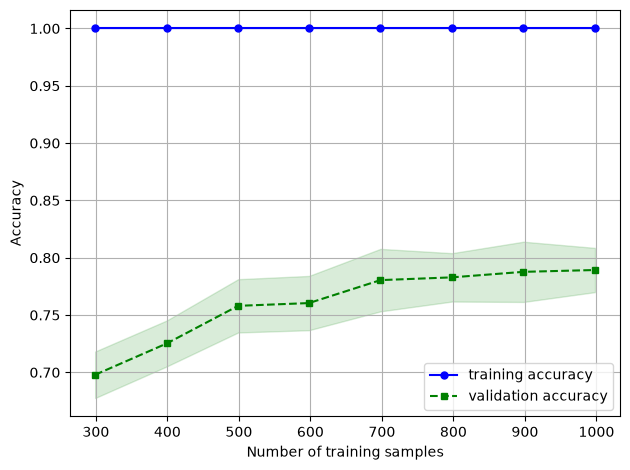

In [9]:
plot_filled(train_scores, test_scores, train_sizes, xlabel='Number of training samples')

Whoa! We are doing something extremely wrong here, the dataset appears to be completely overlearned! Maybe we should try a validation curve to get the right tradeoff in regularization for logistic regression.

In [10]:
from sklearn.model_selection import validation_curve



param_range = [0.00001, 0.0001, 0.001, 0.01, 0.1, 1.0,]
train_scores, test_scores = validation_curve(
                estimator=pipe_lr, 
                X=X_train, 
                y=y_train, 
                param_name='clf__C', 
                param_range=param_range,
                cv=5,n_jobs=-1)

/Users/eclarson/anaconda3/envs/mlenv3_12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/eclarson/anaconda3/envs/mlenv3_12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-lear

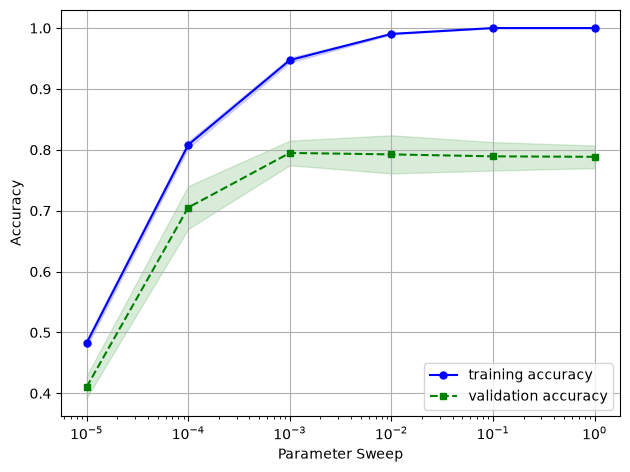

In [11]:
plot_filled(train_scores, test_scores, param_range, xlabel='Parameter Sweep')
plt.xscale('log')
plt.show()

/Users/eclarson/anaconda3/envs/mlenv3_12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/eclarson/anaconda3/envs/mlenv3_12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-lear

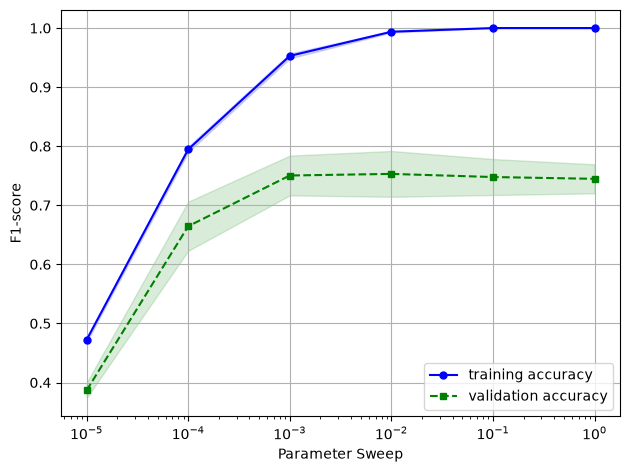

In [12]:
# but how are we doing in terms of precision and recall across the classes?
from sklearn.metrics import make_scorer,f1_score

scorer = make_scorer(f1_score, average='macro')

train_scores, test_scores = validation_curve(
                estimator=pipe_lr, 
                X=X_train, 
                y=y_train, 
                scoring = scorer,
                param_name='clf__C', 
                param_range=param_range,
                cv=5,n_jobs=-1)

plot_filled(train_scores, test_scores, param_range, xlabel='Parameter Sweep')
plt.xscale('log')
plt.ylabel('F1-score')
plt.show()

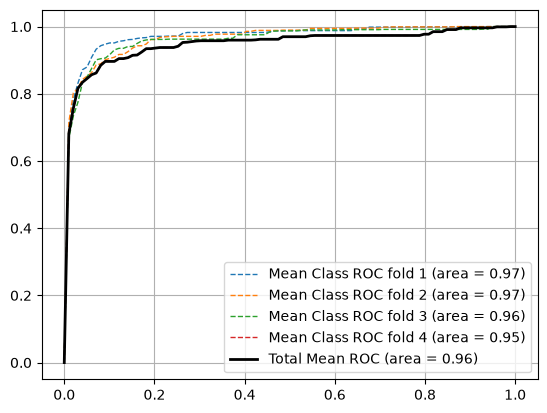

In [13]:
# Great! Its seems we are also maxing out the F1 score, lets go with C==1e-3
from sklearn.metrics import roc_curve, auc
from numpy import interp

K = 4

from sklearn.model_selection import StratifiedKFold
kfold = StratifiedKFold(n_splits=K).split(X_train, y_train)


mean_tpr = 0.0
mean_fpr = np.linspace(0, 1, 100)
all_tpr = []

for i, (train, test) in enumerate(kfold):
    probas = pipe_lr.fit(X_train[train],
                         y_train[train]).predict_proba(X_train[test])

    perclass_mean_tpr = 0.0
    roc_auc = 0
    classes = np.unique(y_train[train])
    # get the mean fpr and tpr, per class
    for j in classes:
        fpr, tpr, thresholds = roc_curve(y_train[test],
                                         probas[:, j],
                                         pos_label=j)
        perclass_mean_tpr += interp(mean_fpr, fpr, tpr)
        perclass_mean_tpr[0] = 0.0
        roc_auc += auc(fpr, tpr)
        
    perclass_mean_tpr /= len(classes)
    roc_auc /= len(classes)
    mean_tpr += perclass_mean_tpr
    plt.plot(mean_fpr,perclass_mean_tpr,'--',lw=1,label='Mean Class ROC fold %d (area = %0.2f)'
                   % (i+1, roc_auc))
    
mean_tpr /= K
mean_auc = auc(mean_fpr, mean_tpr)
plt.plot(mean_fpr,perclass_mean_tpr,'k-',lw=2,label='Total Mean ROC (area = %0.2f)'
                   % (mean_auc))
plt.legend(loc='best')
plt.grid()